# 06 -- Effective diffusion landscape D(x)

The companion PNAS paper characterizes mean velocity-distance curves but never
examines the **noise structure** of chromosome motion.  The SFI framework
infers both drift (interaction kernels) and diffusion, so we can ask:

1. Is the effective diffusion coefficient D spatially varying?
2. Is that spatial structure robust across different local-D estimators?
3. Is the signal consistent across individual cells, or dominated by one or
   two outliers?

If D(x) shows a real gradient -- e.g., higher fluctuations in the periphery
that collapse near the spindle center -- that would be a genuinely new
observable reflecting the stochastic averaging over skMT-spindle contacts.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import TrimmedCell, trim_trajectory, spindle_frame
from chromlearn.model_fitting import FitConfig
from chromlearn.model_fitting.basis import BSplineBasis
from chromlearn.model_fitting.diffusion import (
    COORDINATE_MAPS,
    DiffusionResult,
    estimate_diffusion_variable,
    local_diffusion_estimates,
)
from chromlearn.model_fitting.fit import fit_model
from chromlearn.model_fitting.plotting import plot_diffusion, plot_kernels
from chromlearn.model_fitting.simulate import simulate_cell

plt.rcParams["figure.dpi"] = 110

## Configuration

In [2]:
CONDITION = "rpe18_ctr"          # Control-condition cells used for the diffusion analysis.
FRAC_NEB_AO_WINDOW = 0.4         # Baseline trajectory window as a fraction of NEB-to-AO.
TOPOLOGY = "poles_and_chroms"    # Base FitConfig topology; short-range variant is encoded by the envelope (matches NB04's poles_and_chroms_enveloped winner).
ENVELOPE_R0_XX = 1.5             # Center of the smooth steric envelope on the xx kernel (um); matches NB04.
ENVELOPE_W_XX = 0.3              # Transition width of the envelope (um); matches NB04.
N_BASIS_XX = 10                  # Number of spline basis functions for chromosome-chromosome kernels.
N_BASIS_XY = 10                  # Number of spline basis functions for pole-chromosome kernels.
R_MIN = 0.3                      # Lower basis cutoff in microns.
R_MAX = 15.0                     # Upper basis cutoff in microns.
BASIS_TYPE = "bspline"           # Functional basis used for the learned kernels.
LAMBDA_RIDGE = 1e-6              # Fixed numerical jitter; not a tuning knob.
LAMBDA_ROUGH = 1.0               # Integrated 2nd-derivative penalty (controls kernel smoothness).
BASIS_EVAL_MODE = "ito"          # Drift-evaluation convention used in the fit.
DT = 5.0                         # Frame interval in seconds.

In [3]:
cells_raw = load_condition(CONDITION)
cells = [trim_trajectory(c, method="neb_ao_frac", frac=FRAC_NEB_AO_WINDOW) for c in cells_raw]
print(f"Loaded {len(cells)} {CONDITION} cells (trimmed to neb_ao_frac={FRAC_NEB_AO_WINDOW:.3f})")

# Same fit config as NB04's poles_and_chroms_enveloped winner: base topology
# poles_and_chroms with smooth steric envelope (r0=1.5 um, w=0.3 um), 10 basis
# functions, 1e-6 ridge jitter.
config = FitConfig(
    topology=TOPOLOGY,
    envelope_r0_xx=ENVELOPE_R0_XX,
    envelope_w_xx=ENVELOPE_W_XX,
    n_basis_xx=N_BASIS_XX,
    n_basis_xy=N_BASIS_XY,
    r_min_xx=R_MIN,
    r_max_xx=R_MAX,
    r_min_xy=R_MIN,
    r_max_xy=R_MAX,
    basis_type=BASIS_TYPE,
    lambda_ridge=LAMBDA_RIDGE,
    lambda_rough=LAMBDA_ROUGH,
    basis_eval_mode=BASIS_EVAL_MODE,
    endpoint_method="neb_ao_frac",
    endpoint_frac=FRAC_NEB_AO_WINDOW,
    dt=DT,
)

model = fit_model(cells, config)
print(f"Scalar D = {model.D_x:.6f} um^2/s")

Loaded 12 rpe18_ctr cells (trimmed to neb_ao_frac=0.400)


Scalar D = 0.001971 um^2/s


## Local D estimates from all four estimators

We compute per-particle, per-timepoint D estimates using four methods:

| Estimator      | Formula                                          | Bias properties |
|----------------|--------------------------------------------------|-----------------|
| MSD            | |dX|^2 / (2d dt)                                 | Simple, 2-point |
| Vestergaard    | 3-point, cancels localization noise               | Noise-robust    |
| Weak-noise     | |dX - dX_prev|^2 / (4d dt)                       | Drift-robust    |
| F-corrected    | |dX - F_pred*dt|^2 / (2d dt)                     | Subtracts drift |

If the spatial gradient is robust across estimators, it is more likely
biological.  If it only appears in one estimator, suspect artifact.

In [4]:
ESTIMATORS = ["msd", "vestergaard", "weak_noise", "f_corrected"]
COORD = "distance"  # distance from spindle center

D_locals_by_est: dict[str, list[np.ndarray]] = {}
for est in ESTIMATORS:
    kwargs = {}
    if est == "f_corrected":
        kwargs = dict(
            fit_result=model,
            basis_xx=model.basis_xx,
            basis_xy=model.basis_xy,
            topology=model.topology,
        )
    D_locals_by_est[est] = local_diffusion_estimates(
        cells, dt=config.dt, mode=est, **kwargs
    )
    all_vals = np.concatenate([d.ravel() for d in D_locals_by_est[est]])
    valid = all_vals[np.isfinite(all_vals)]
    print(f"{est:14s}: {len(valid):>7,} valid samples, "
          f"mean D = {np.mean(valid):.6f}, median = {np.median(valid):.6f} um^2/s")

msd           :  55,413 valid samples, mean D = 0.001999, median = 0.001079 um^2/s
vestergaard   :  54,860 valid samples, mean D = 0.002394, median = 0.001289 um^2/s
weak_noise    :  54,860 valid samples, mean D = 0.001607, median = 0.000903 um^2/s


f_corrected   :  55,413 valid samples, mean D = 0.001971, median = 0.001092 um^2/s


## Fit D(distance) with basis expansion for each estimator

We use a B-spline basis along the distance-from-spindle-center coordinate
and ridge regression to get a smooth D(x) profile.

In [5]:
D_COORD = "distance"
N_BASIS_D = 8
R_MIN_D = 0.5
R_MAX_D = 12.0

basis_D = BSplineBasis(R_MIN_D, R_MAX_D, N_BASIS_D)

# Restrict the plot range to where data actually exists. The fit basis spans
# [R_MIN_D, R_MAX_D] but cells rarely reach the upper end, and the unconstrained
# ridge solution can extrapolate into the negative on the sparse tail. We use
# the 1st-99th percentile of the empirical distance distribution.
_coord_fn = COORDINATE_MAPS[D_COORD]
_all_coords = np.concatenate(
    [_coord_fn(c.chromosomes, c).ravel() for c in cells]
)
_all_coords = _all_coords[np.isfinite(_all_coords)]
EVAL_LO, EVAL_HI = np.quantile(_all_coords, [0.01, 0.99])
EVAL_LO = max(EVAL_LO, R_MIN_D)
EVAL_HI = min(EVAL_HI, R_MAX_D)
eval_coords = np.linspace(EVAL_LO, EVAL_HI, 200)
print(f"D(x) plot range clipped to data quantiles: [{EVAL_LO:.2f}, {EVAL_HI:.2f}] um")

diff_results: dict[str, DiffusionResult] = {}
for est in ESTIMATORS:
    kwargs = {}
    if est == "f_corrected":
        kwargs = dict(
            fit_result=model,
            basis_xx=model.basis_xx,
            basis_xy=model.basis_xy,
        )
    diff_results[est] = estimate_diffusion_variable(
        cells,
        basis_D=BSplineBasis(R_MIN_D, R_MAX_D, N_BASIS_D),
        coord_name=D_COORD,
        dt=config.dt,
        mode=est,
        lambda_ridge=LAMBDA_RIDGE,
        topology=model.topology,
        **kwargs,
    )

D(x) plot range clipped to data quantiles: [1.07, 7.74] um


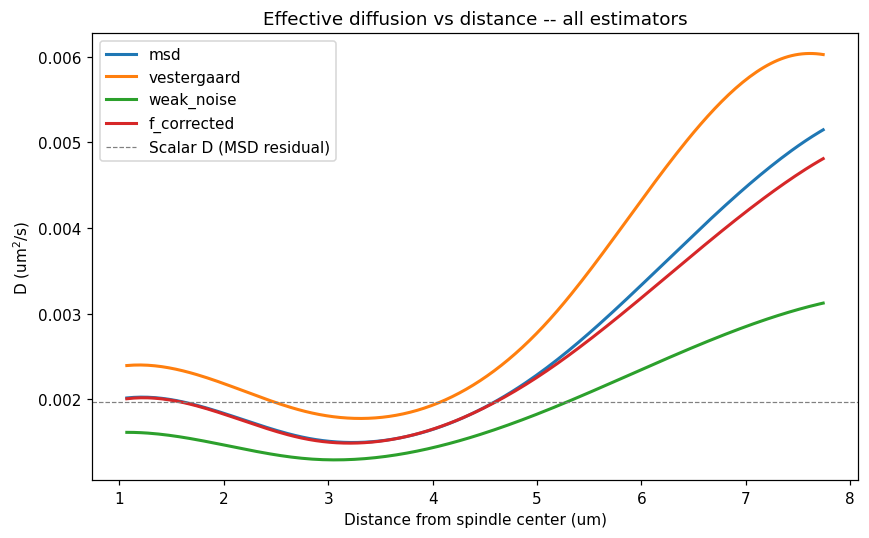

In [6]:
# Overlay all four estimator D(x) profiles
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"msd": "C0", "vestergaard": "C1", "weak_noise": "C2", "f_corrected": "C3"}

for est in ESTIMATORS:
    D_vals = diff_results[est].evaluate(eval_coords)
    ax.plot(eval_coords, D_vals, color=colors[est], linewidth=2, label=est)

ax.axhline(model.D_x, color="0.5", linestyle="--", linewidth=0.8, label="Scalar D (MSD residual)")
ax.set_xlabel("Distance from spindle center (um)")
ax.set_ylabel("D (um$^2$/s)")
ax.set_title("Effective diffusion vs distance -- all estimators")
ax.legend()
fig.tight_layout()
plt.show()

**Note on plot range:** The fit basis spans the full ``[R_MIN_D, R_MAX_D]``
domain, but cells rarely visit the upper end of that range, and the
unconstrained ridge solution can extrapolate into the negative on the sparse
tail. The plot above is clipped to the empirical 1-99 percentile of the
distance distribution so the displayed curves correspond to coordinates that
are actually sampled by the data.

## Drift vs diffusion: how much of one-step motion is deterministic?

For overdamped Langevin dynamics dX = F dt + sqrt(2 D dt) dW, the expected
squared one-step displacement decomposes into a deterministic and a
stochastic part:

    E[|dX|^2] = |F|^2 dt^2 + 6 D dt   (3D)

Three equivalent dimensionless and length quantities summarize how strongly
drift dominates over diffusion at one time step:

- **Drift fraction**: f_drift = |F|^2 dt / (|F|^2 dt + 6 D), in [0, 1].
  Fraction of one-step squared displacement that is deterministic.
- **One-step Peclet number**: Pe = |F| sqrt(dt / (2 D)). Pe >> 1 means drift
  dominates, Pe << 1 means diffusion dominates.
- **Crossover length**: L* = 2 D / |F|. Length scale below which diffusive
  motion competes with drift; compare to spindle dimensions (~10 um).

We use the fitted drift field |F(x)| (kernels evaluated at every real
chromosome position over all timepoints) and the scalar D from the
residual MSD.

In [7]:
from chromlearn.model_fitting.diffusion import _predicted_force

force_mags_chunks = []
distances_chunks = []
for cell in cells:
    coord_arr = COORDINATE_MAPS[D_COORD](cell.chromosomes, cell)  # (T, N)
    T_cell = cell.chromosomes.shape[0]
    for t in range(T_cell):
        F = _predicted_force(
            cell, t,
            fit_result=model,
            basis_xx=model.basis_xx,
            basis_xy=model.basis_xy,
            topology=model.topology,
        )
        Fmag = np.linalg.norm(F, axis=1)  # (N,)
        valid = np.isfinite(Fmag) & np.isfinite(coord_arr[t])
        force_mags_chunks.append(Fmag[valid])
        distances_chunks.append(coord_arr[t][valid])

force_mags = np.concatenate(force_mags_chunks)
distances_force = np.concatenate(distances_chunks)

D_scalar = model.D_x
dt_step = config.dt
f_drift_all = (force_mags ** 2 * dt_step) / (force_mags ** 2 * dt_step + 6.0 * D_scalar)
Pe_all = force_mags * np.sqrt(dt_step / (2.0 * D_scalar))
L_star_all = 2.0 * D_scalar / np.maximum(force_mags, 1e-12)

print(f"Sample size: {force_mags.size:,} (chromosome x timepoint)")
print(f"Scalar D = {D_scalar:.4f} um^2/s, dt = {dt_step:.1f} s")
print()
print("                     median       IQR")
for name, vals, fmt in [
    ("|F| (um/s)",      force_mags,  "{:.4f}"),
    ("f_drift",         f_drift_all, "{:.3f}"),
    ("Peclet (1-step)", Pe_all,      "{:.2f}"),
    ("L* (um)",         L_star_all,  "{:.3f}"),
]:
    q25, q50, q75 = np.quantile(vals, [0.25, 0.5, 0.75])
    print(f"  {name:<18} {fmt.format(q50):>8}    [{fmt.format(q25)}, {fmt.format(q75)}]")

Sample size: 55,966 (chromosome x timepoint)
Scalar D = 0.0020 um^2/s, dt = 5.0 s

                     median       IQR
  |F| (um/s)           0.0053    [0.0041, 0.0065]
  f_drift               0.012    [0.007, 0.018]
  Peclet (1-step)        0.19    [0.15, 0.23]
  L* (um)               0.745    [0.607, 0.965]


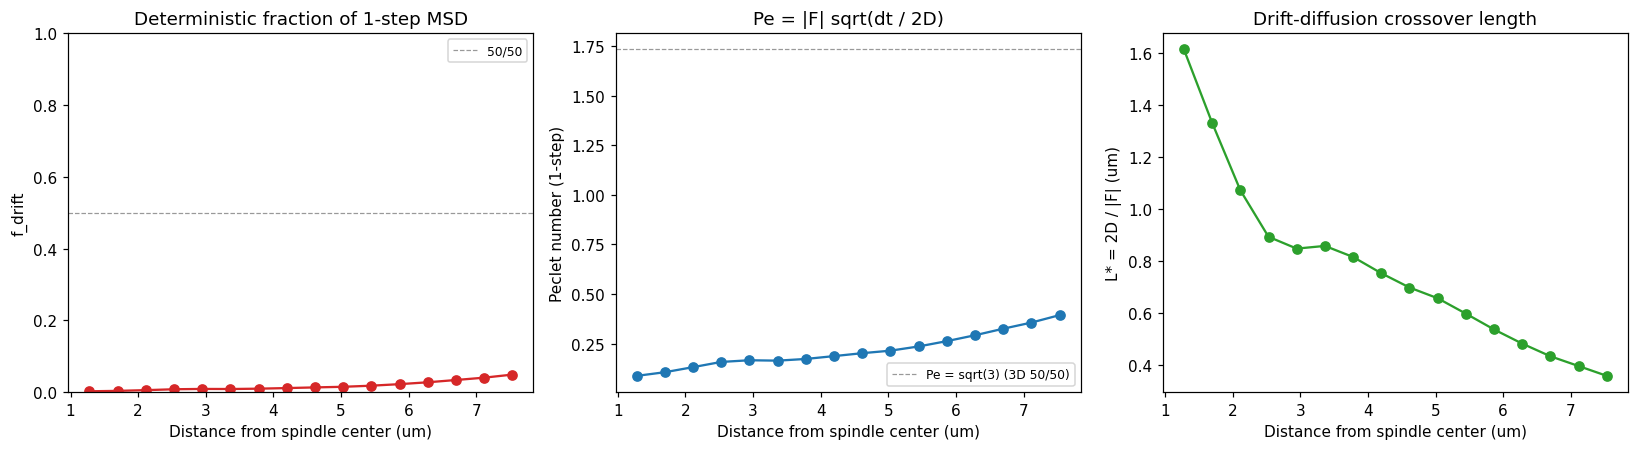

In [8]:
# Distance-binned medians of f_drift, Pe, L*
N_BINS = 16
bin_edges = np.linspace(EVAL_LO, EVAL_HI, N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_idx = np.clip(np.digitize(distances_force, bin_edges) - 1, 0, N_BINS - 1)


def _binmedian(values: np.ndarray, idx: np.ndarray, n_bins: int) -> np.ndarray:
    out = np.full(n_bins, np.nan)
    for b in range(n_bins):
        mask = (idx == b) & np.isfinite(values)
        if mask.any():
            out[b] = np.median(values[mask])
    return out


f_drift_med = _binmedian(f_drift_all, bin_idx, N_BINS)
Pe_med = _binmedian(Pe_all, bin_idx, N_BINS)
L_star_med = _binmedian(L_star_all, bin_idx, N_BINS)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4.2))
axes2[0].plot(bin_centers, f_drift_med, "o-", color="C3")
axes2[0].axhline(0.5, color="0.6", linestyle="--", linewidth=0.8, label="50/50")
axes2[0].set_ylim(0, 1)
axes2[0].set_xlabel("Distance from spindle center (um)")
axes2[0].set_ylabel("f_drift")
axes2[0].set_title("Deterministic fraction of 1-step MSD")
axes2[0].legend(fontsize=8)

axes2[1].plot(bin_centers, Pe_med, "o-", color="C0")
# Pe = |F| sqrt(dt/2D) compares per-coordinate drift and diffusion. For the
# 3D total-MSD 50/50 crossover (matching f_drift = 0.5) the threshold is
# Pe = sqrt(3) ~= 1.73.
axes2[1].axhline(np.sqrt(3.0), color="0.6", linestyle="--", linewidth=0.8,
                 label="Pe = sqrt(3) (3D 50/50)")
axes2[1].set_xlabel("Distance from spindle center (um)")
axes2[1].set_ylabel("Peclet number (1-step)")
axes2[1].set_title("Pe = |F| sqrt(dt / 2D)")
axes2[1].legend(fontsize=8)

axes2[2].plot(bin_centers, L_star_med, "o-", color="C2")
axes2[2].set_xlabel("Distance from spindle center (um)")
axes2[2].set_ylabel("L* = 2D / |F| (um)")
axes2[2].set_title("Drift-diffusion crossover length")

fig2.tight_layout()
plt.show()

## Per-cell D(x) consistency

We check whether the spatial gradient is consistent across individual cells
or driven by one or two outliers.  For each cell, we fit D(distance) using
the Vestergaard estimator (a good compromise between noise-robustness and
simplicity).

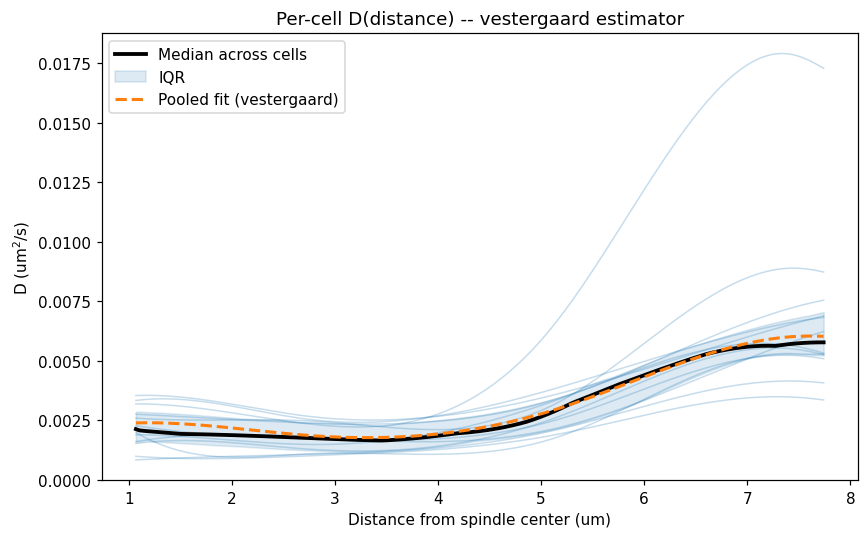

In [9]:
PERCELL_EST = "vestergaard"
fig, ax = plt.subplots(figsize=(8, 5))

percell_D_curves = []
for cell in cells:
    dr = estimate_diffusion_variable(
        [cell],
        basis_D=BSplineBasis(R_MIN_D, R_MAX_D, N_BASIS_D),
        coord_name=D_COORD,
        dt=config.dt,
        mode=PERCELL_EST,
        lambda_ridge=LAMBDA_RIDGE,
        topology=model.topology,
    )
    D_curve = dr.evaluate(eval_coords)
    percell_D_curves.append(D_curve)
    ax.plot(eval_coords, D_curve, color="C0", alpha=0.25, linewidth=1)

percell_D_curves = np.array(percell_D_curves)
ax.plot(eval_coords, np.median(percell_D_curves, axis=0),
        color="k", linewidth=2.5, label="Median across cells")
ax.fill_between(
    eval_coords,
    np.percentile(percell_D_curves, 25, axis=0),
    np.percentile(percell_D_curves, 75, axis=0),
    color="C0", alpha=0.15, label="IQR",
)
# Overlay pooled fit
pooled_D = diff_results[PERCELL_EST].evaluate(eval_coords)
ax.plot(eval_coords, pooled_D, color="C1", linewidth=2, linestyle="--",
        label=f"Pooled fit ({PERCELL_EST})")

ax.set_xlabel("Distance from spindle center (um)")
ax.set_ylabel("D (um$^2$/s)")
ax.set_title(f"Per-cell D(distance) -- {PERCELL_EST} estimator")
ax.legend()
fig.tight_layout()
plt.show()

## D along alternative coordinate axes

Check whether the signal looks different along the axial (spindle-axis
projection) vs radial (perpendicular distance from spindle axis) coordinates.

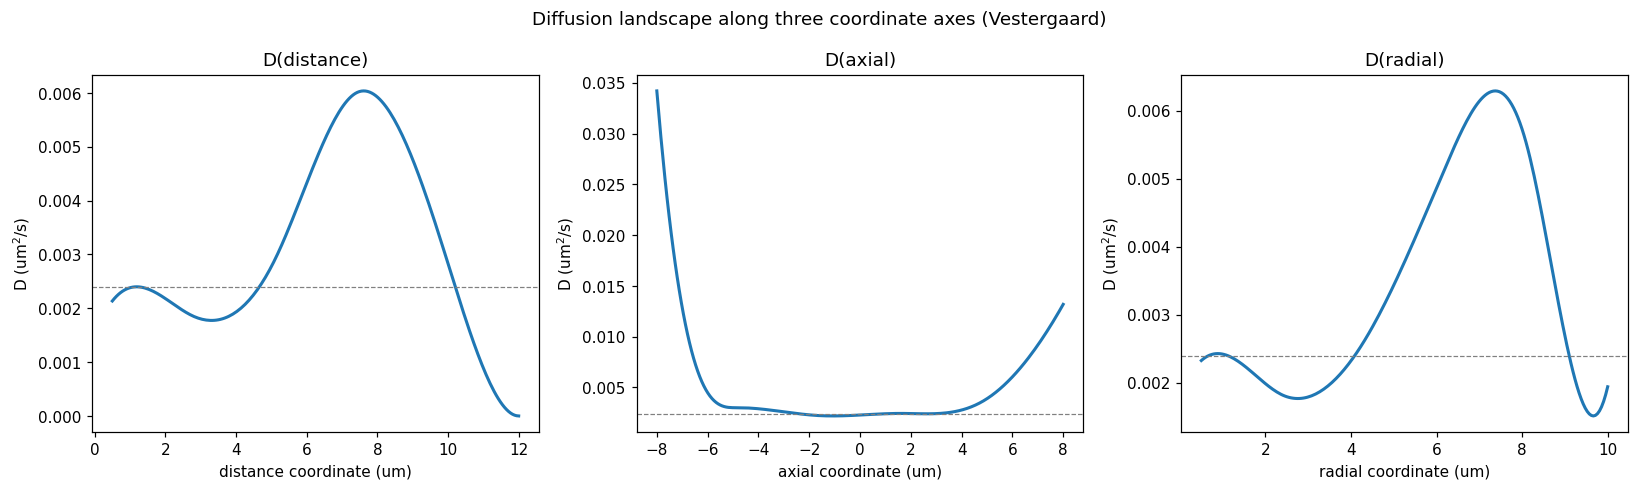

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
coord_names = ["distance", "axial", "radial"]
coord_domains = {
    "distance": (0.5, 12.0),
    "axial": (-8.0, 8.0),
    "radial": (0.5, 10.0),
}

for idx, coord in enumerate(coord_names):
    rlo, rhi = coord_domains[coord]
    dr = estimate_diffusion_variable(
        cells,
        basis_D=BSplineBasis(rlo, rhi, N_BASIS_D),
        coord_name=coord,
        dt=config.dt,
        mode="vestergaard",
        lambda_ridge=LAMBDA_RIDGE,
        topology=model.topology,
    )
    x = np.linspace(rlo, rhi, 200)
    axes[idx].plot(x, dr.evaluate(x), color="C0", linewidth=2)
    axes[idx].axhline(dr.D_scalar, color="0.5", linestyle="--", linewidth=0.8)
    axes[idx].set_xlabel(f"{coord} coordinate (um)")
    axes[idx].set_ylabel("D (um$^2$/s)")
    axes[idx].set_title(f"D({coord})")

fig.suptitle("Diffusion landscape along three coordinate axes (Vestergaard)")
fig.tight_layout()
plt.show()

## Rollout validation: scalar D model

As a sanity check, we simulate a few representative cells with the fitted
model (scalar D) and compare spindle-frame trajectories to real data.

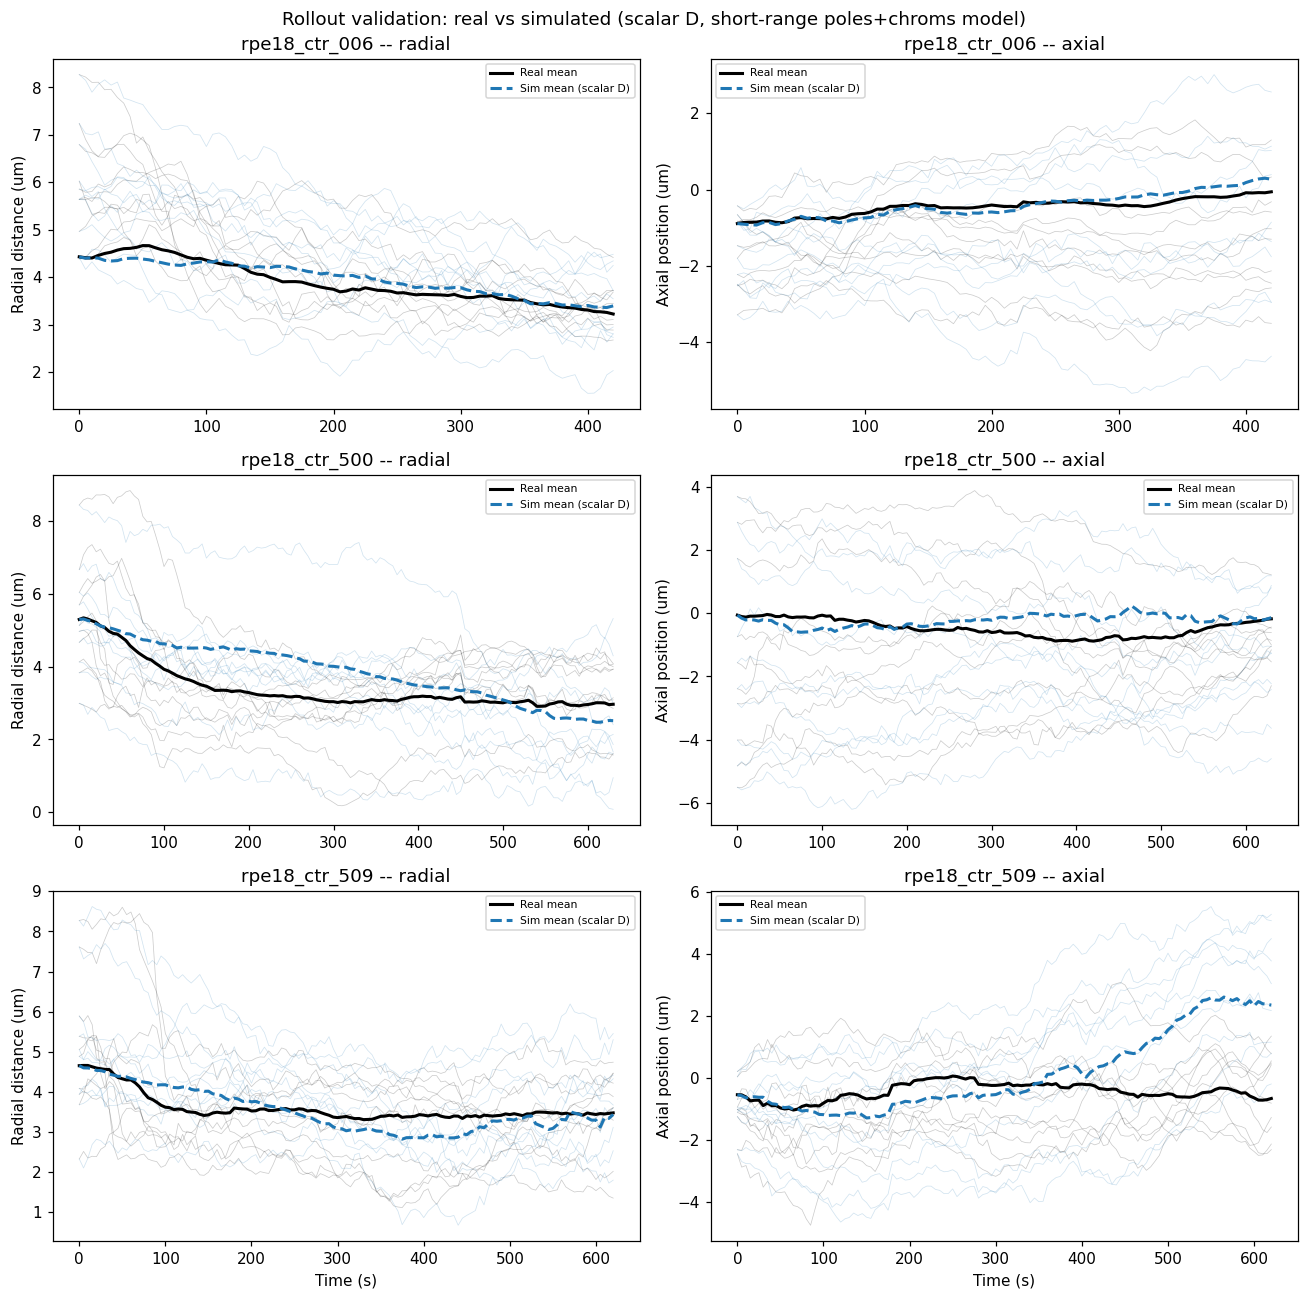

In [11]:
from chromlearn.model_fitting.simulate import simulate_cell

# Pick a few representative cells
ROLLOUT_CELLS = [0, len(cells) // 2, len(cells) - 1]
ROLLOUT_SEED = 42

fig, axes = plt.subplots(len(ROLLOUT_CELLS), 2, figsize=(12, 4 * len(ROLLOUT_CELLS)),
                         squeeze=False)

for row, cell_idx in enumerate(ROLLOUT_CELLS):
    cell = cells[cell_idx]
    T, _, N = cell.chromosomes.shape

    _, sim_cell = simulate_cell(cell, model,
                                rng=np.random.default_rng(ROLLOUT_SEED + cell_idx))

    sf_real = spindle_frame(cell)
    sf_sim = spindle_frame(sim_cell)

    time_axis = np.arange(T) * config.dt

    # Plot radial (distance to spindle axis) for a subset of chromosomes
    n_show = min(10, N)
    for i in range(n_show):
        axes[row, 0].plot(time_axis, sf_real.radial[:, i], "k-", alpha=0.2, linewidth=0.5)
        axes[row, 0].plot(time_axis, sf_sim.radial[:, i], "C0-", alpha=0.2, linewidth=0.5)
    axes[row, 0].plot(time_axis, np.nanmean(sf_real.radial, axis=1),
                      "k-", linewidth=2, label="Real mean")
    axes[row, 0].plot(time_axis, np.nanmean(sf_sim.radial, axis=1),
                      "C0--", linewidth=2, label="Sim mean (scalar D)")
    axes[row, 0].set_ylabel("Radial distance (um)")
    axes[row, 0].set_title(f"{cell.cell_id} -- radial")
    axes[row, 0].legend(fontsize=7)

    # Plot axial
    for i in range(n_show):
        axes[row, 1].plot(time_axis, sf_real.axial[:, i], "k-", alpha=0.2, linewidth=0.5)
        axes[row, 1].plot(time_axis, sf_sim.axial[:, i], "C0-", alpha=0.2, linewidth=0.5)
    axes[row, 1].plot(time_axis, np.nanmean(sf_real.axial, axis=1),
                      "k-", linewidth=2, label="Real mean")
    axes[row, 1].plot(time_axis, np.nanmean(sf_sim.axial, axis=1),
                      "C0--", linewidth=2, label="Sim mean (scalar D)")
    axes[row, 1].set_ylabel("Axial position (um)")
    axes[row, 1].set_title(f"{cell.cell_id} -- axial")
    axes[row, 1].legend(fontsize=7)

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Rollout validation: real vs simulated (scalar D, short-range poles+chroms model)")
fig.tight_layout()
plt.show()

## Diffusion-gradient correction magnitude

In a full SFI treatment, D(x) enters the force inference jointly: the Ito
drift includes a "spurious force" term grad(D).  Our two-stage approach
(fit force first, then estimate D from residuals) neglects this correction.
Here we check whether grad(D) is small compared to the inferred force,
which would justify the decoupled approach.

**Coordinate caveat:** D is fit as a function of distance from spindle
center, while F_xy is a pairwise kernel evaluated at individual
pole-chromosome distances (and each chromosome interacts with both poles).
These are different 1D coordinates, so the comparison below is an
order-of-magnitude check, not an exact decomposition.

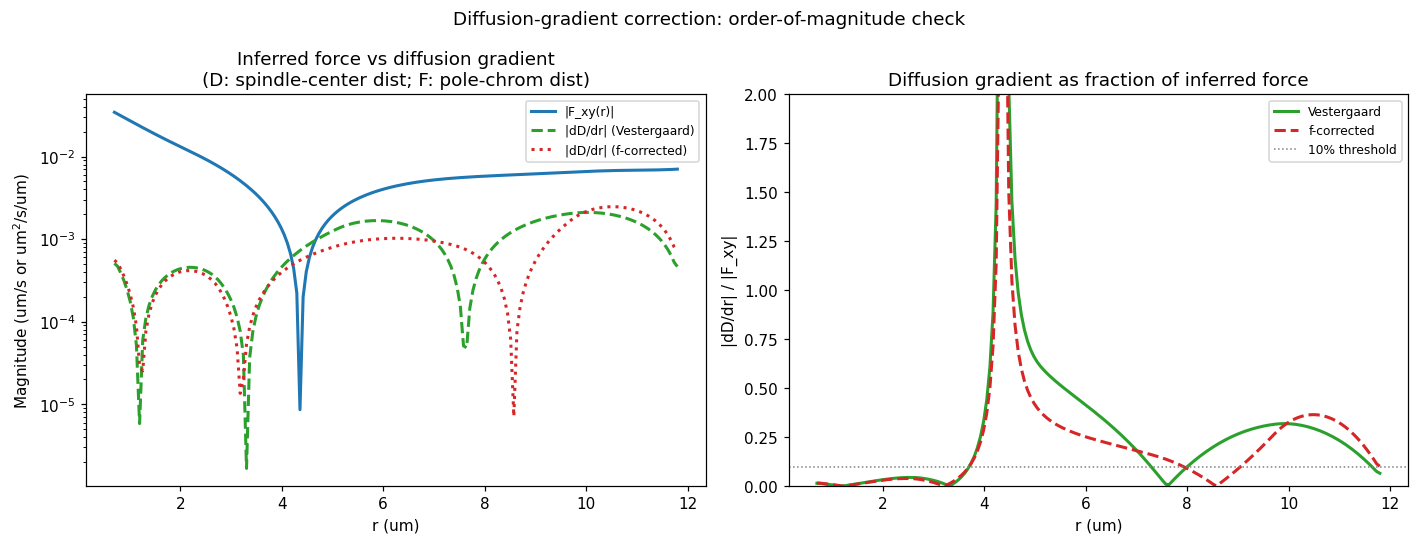

In [12]:
# Numerical derivative of D(distance) from the Vestergaard fit
dr_vest = diff_results["vestergaard"]
eval_r = np.linspace(R_MIN_D + 0.2, R_MAX_D - 0.2, 180)
D_vals = dr_vest.evaluate(eval_r)

# Central-difference gradient dD/dr
dr_step = eval_r[1] - eval_r[0]
dD_dr = np.gradient(D_vals, dr_step)

# Inferred centrosome-chromosome force at the same distances
F_xy = model.evaluate_kernel("xy", eval_r)

# Also compute for f_corrected estimator as a cross-check
dr_fcorr = diff_results["f_corrected"]
D_vals_fc = dr_fcorr.evaluate(eval_r)
dD_dr_fc = np.gradient(D_vals_fc, dr_step)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: force vs dD/dr
ax = axes[0]
ax.plot(eval_r, np.abs(F_xy), "C0-", linewidth=2, label="|F_xy(r)|")
ax.plot(eval_r, np.abs(dD_dr), "C2--", linewidth=2, label="|dD/dr| (Vestergaard)")
ax.plot(eval_r, np.abs(dD_dr_fc), "C3:", linewidth=2, label="|dD/dr| (f-corrected)")
ax.set_xlabel("r (um)")
ax.set_ylabel("Magnitude (um/s or um$^2$/s/um)")
ax.set_title("Inferred force vs diffusion gradient\n(D: spindle-center dist; F: pole-chrom dist)")
ax.legend(fontsize=8)
ax.set_yscale("log")

# Right panel: ratio |dD/dr| / |F_xy|
ax = axes[1]
safe_F = np.where(np.abs(F_xy) > 1e-12, np.abs(F_xy), np.nan)
ratio_vest = np.abs(dD_dr) / safe_F
ratio_fc = np.abs(dD_dr_fc) / safe_F
ax.plot(eval_r, ratio_vest, "C2-", linewidth=2, label="Vestergaard")
ax.plot(eval_r, ratio_fc, "C3--", linewidth=2, label="f-corrected")
ax.axhline(0.1, color="0.5", linestyle=":", linewidth=1, label="10% threshold")
ax.set_xlabel("r (um)")
ax.set_ylabel("|dD/dr| / |F_xy|")
ax.set_title("Diffusion gradient as fraction of inferred force")
ax.legend(fontsize=8)
ax.set_ylim(0, min(2.0, np.nanmax(ratio_vest) * 1.2))

fig.suptitle("Diffusion-gradient correction: order-of-magnitude check")
fig.tight_layout()
plt.show()

In [13]:
# Print summary statistics
median_ratio_vest = float(np.nanmedian(ratio_vest))
median_ratio_fc = float(np.nanmedian(ratio_fc))
max_ratio_vest = float(np.nanmax(ratio_vest[np.isfinite(ratio_vest)]))
max_ratio_fc = float(np.nanmax(ratio_fc[np.isfinite(ratio_fc)]))
print(f"Vestergaard:  median |dD/dr|/|F| = {median_ratio_vest:.3f}, "
      f"max = {max_ratio_vest:.3f}")
print(f"F-corrected:  median |dD/dr|/|F| = {median_ratio_fc:.3f}, "
      f"max = {max_ratio_fc:.3f}")
print("(Note: D is evaluated along spindle-center distance, F_xy along")
print("pole-chromosome distance. This comparison is order-of-magnitude.)")
if median_ratio_vest < 0.1 and median_ratio_fc < 0.1:
    print("=> Diffusion gradient is small relative to inferred force.")
    print("   Two-stage (force first, then D) approach is justified.")
else:
    print("=> Diffusion gradient is NOT negligible relative to inferred force.")
    print("   The decoupled two-stage approach may introduce bias; consider")
    print("   joint inference or reporting this as a methodological caveat.")

Vestergaard:  median |dD/dr|/|F| = 0.210, max = 84.628
F-corrected:  median |dD/dr|/|F| = 0.169, max = 64.422
(Note: D is evaluated along spindle-center distance, F_xy along
pole-chromosome distance. This comparison is order-of-magnitude.)
=> Diffusion gradient is NOT negligible relative to inferred force.
   The decoupled two-stage approach may introduce bias; consider
   joint inference or reporting this as a methodological caveat.


## Summary

**Questions answered:**

1. Is D(x) spatially varying? -- Check the multi-estimator overlay above.
2. Is the gradient robust? -- If all four estimator curves show the same
   qualitative shape, the signal is credible.
3. Is it per-cell consistent? -- Check whether the per-cell curves cluster
   tightly or scatter widely.

**Interpretation guide:**

- Higher D in the periphery + lower D near the center would suggest that
  far-out chromosomes experience more stochastic fluctuation per step,
  consistent with fewer effective skMT-spindle averaging contacts.
- Flat D would mean the noise is spatially homogeneous and the scalar D is
  sufficient.
- D(axial) showing structure while D(radial) does not (or vice versa)
  would point to anisotropic noise worth further investigation.